##### imports

In [1]:
# Pre-flight checklist. Do not change this code.
# Make sure that you have installed recent versions of key packages.
%matplotlib inline
import shutil
import kagglehub
import os
import json
import random
import math
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
import pytorch_lightning as pl
import torchvision.models as models
import torchvision.transforms as transforms
import openml_pytorch as opt
from tqdm import tqdm

from torch import nn
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict
from pathlib import Path
from packaging import version
from sklearn.model_selection import train_test_split
from IPython.display import Markdown, display
from PIL import Image

warnings.simplefilter(action='ignore', category=FutureWarning)


torch_version = torch.__version__
if version.parse(torch_version) < version.parse("2.6.0"):
    print("torch is outdated: {}. Please update now! pip install -U torch".format(torch_version))
else:
    print("OK. You may continue :)")

torch is outdated: 2.5.1+cpu. Please update now! pip install -U torch


##### load trashnet dataset

In [2]:
path = kagglehub.dataset_download("feyzazkefe/trashnet")

target_dir = os.path.join(os.getcwd(), "..", "data", "trashnet")
os.makedirs(target_dir, exist_ok=True)

shutil.copytree(path, target_dir, dirs_exist_ok=True)

print("Dataset copied to:", target_dir)
base_path = "../data/trashnet/dataset-resized"

Dataset copied to: C:\Users\Richa\PycharmProjects\efteling_project\notebooks\..\data\trashnet


##### check different classes

In [3]:
def show_random_images_per_class(base_path, num_images=5):
    """
    Displays random images per class from a dataset folder.
    
    Args:
        base_path (str): Path to dataset (e.g., './data/trashnet/dataset-resized')
        num_images (int): Number of random images to show per class
    """
    
    classes = [cls for cls in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, cls))]
    
    for cls in classes:
        class_path = os.path.join(base_path, cls)
        images = os.listdir(class_path)
        
        # Randomly sample images
        sampled_images = random.sample(images, min(num_images, len(images)))
        
        # Plot images
        plt.figure(figsize=(15, 3))
        plt.suptitle(f"Class: {cls}", fontsize=14)
        
        for i, img_name in enumerate(sampled_images):
            img_path = os.path.join(class_path, img_name)
            img = Image.open(img_path)
            
            plt.subplot(1, num_images, i + 1)
            plt.imshow(img)
            plt.axis('off')
        
        plt.show()


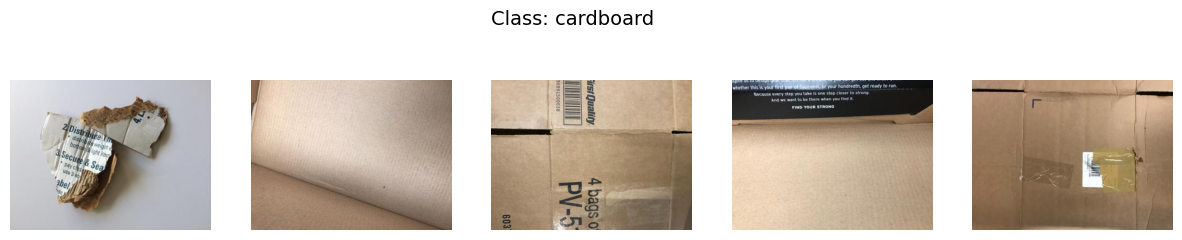

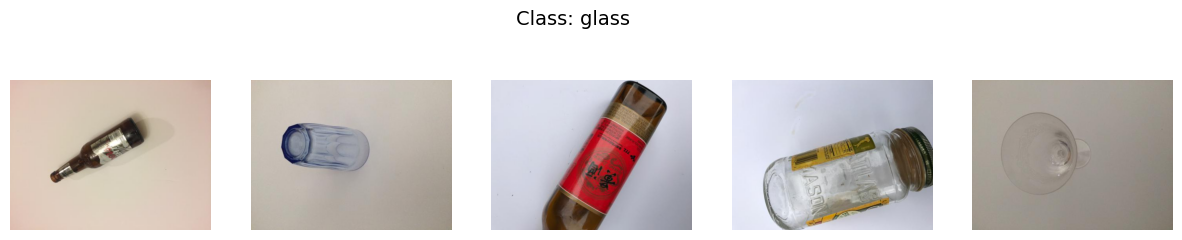

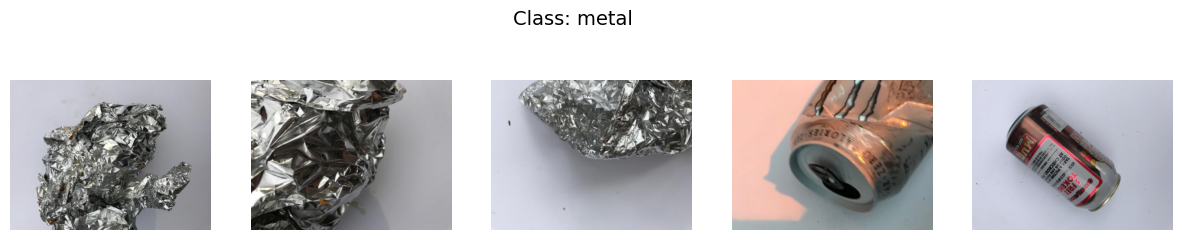

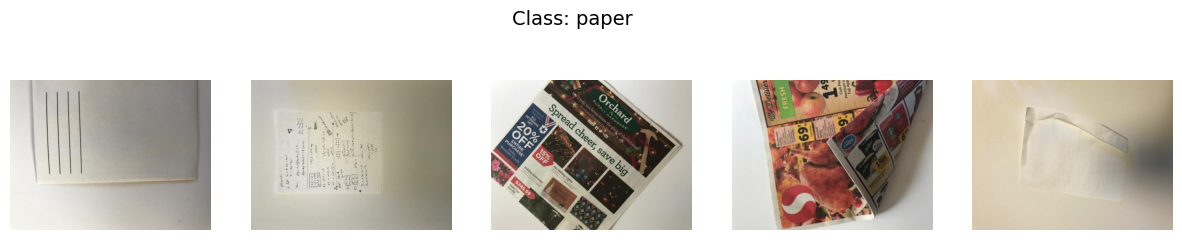

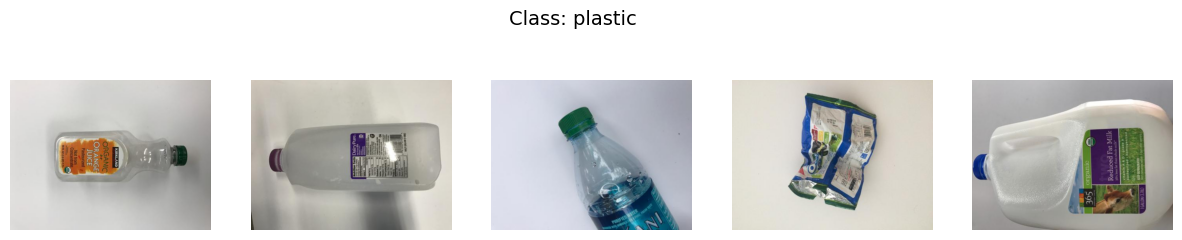

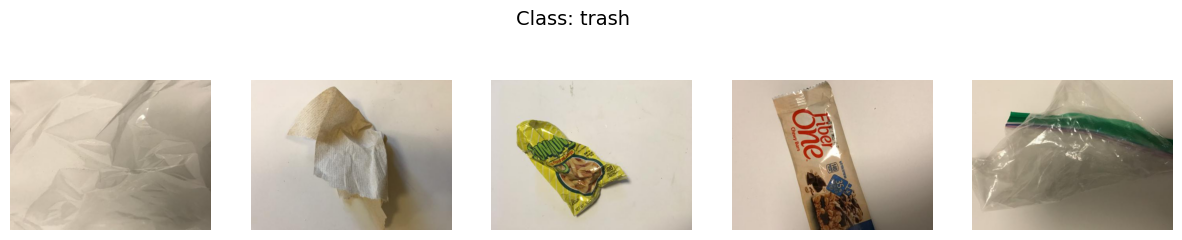

In [4]:
show_random_images_per_class(base_path, num_images=5)